***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.12 宽场方向相关成像](9_12_direction_dependent_widefield_imaging.ipynb)
    * 下一节： [9.x 延伸阅读与后续实践方向](9_x_further_reading_and_workflow.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.13 高级谱线分析：`3D mask`、source finding 与简化运动学拟合

`9.7` 已经把谱线处理从“最小演示”推进到了更完整的基础工作流，但真实的谱线科学分析通常不会停在 moment map 和全局谱线宽度上。到了更专业的训练层次，我们往往还需要继续回答三类问题：

- 哪些体素可以被视为可信发射，应该如何构造一个更稳健的 `3D mask`；
- 一个 line cube 中如果同时存在主盘、伴随云团或离散分量，怎样做基本的 source finding 和组件目录整理；
- 在隔离主分量之后，怎样从 `PV diagram` 出发，做一个最小但有物理意义的运动学拟合。

这一节继续采用完全自包含的合成谱线立方体，不尝试伪装成真实 CASA 或 pipeline 环境，而是把高级谱线工作流最重要的判断链拆开来练：

1. 构造一个含旋转盘和伴随云团的 H I 风格数据立方体；
2. 用平滑辅助的双阈值法建立 `3D mask`；
3. 做连通域标记，生成一个最小组件目录；
4. 只保留主盘分量，抽取 `PV diagram` 和 ridge；
5. 用一个简化的 arctan 旋转曲线模型做入门级拟合。

这不会替代真实工作里的 `SoFiA`、tilted-ring 或 3D forward modeling，但它能把“检测、分离、测量、建模”这条谱线分析链明确地建立起来。


***


In [2]:
def gaussian_map(x, y, x0, y0, sigma_x, sigma_y):
    profile = np.exp(
        -0.5 * (((x - x0) / sigma_x) ** 2 + ((y - y0) / sigma_y) ** 2)
    )
    profile /= profile.max()
    return profile


def gaussian_kernel(npix, sigma_pix):
    coords = np.arange(npix) - npix // 2
    xx, yy = np.meshgrid(coords, coords)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    kernel /= kernel.sum()
    return kernel


def fft_convolve_same(image, kernel):
    image_ft = np.fft.fft2(image)
    kernel_ft = np.fft.fft2(np.fft.ifftshift(kernel), s=image.shape)
    return np.real(np.fft.ifft2(image_ft * kernel_ft))


def robust_rms(data):
    median = np.median(data)
    return 1.4826 * np.median(np.abs(data - median))


def spectral_smooth(array):
    array = np.asarray(array)
    if array.shape[0] < 3:
        return array.copy()

    out = np.empty_like(array)
    out[0] = 0.75 * array[0] + 0.25 * array[1]
    out[-1] = 0.75 * array[-1] + 0.25 * array[-2]
    out[1:-1] = (
        0.25 * array[:-2] + 0.50 * array[1:-1] + 0.25 * array[2:]
    )
    return out


def spatial_smooth(cube, kernel):
    return np.stack([fft_convolve_same(channel, kernel) for channel in cube], axis=0)


def dilate6(mask):
    expanded = mask.copy()
    expanded[1:] |= mask[:-1]
    expanded[:-1] |= mask[1:]
    expanded[:, 1:] |= mask[:, :-1]
    expanded[:, :-1] |= mask[:, 1:]
    expanded[:, :, 1:] |= mask[:, :, :-1]
    expanded[:, :, :-1] |= mask[:, :, 1:]
    return expanded


def connected_components_3d(mask, min_voxels=40, min_chan=3):
    visited = np.zeros(mask.shape, dtype=bool)
    labels = np.zeros(mask.shape, dtype=int)
    neighbors = [
        (dv, dy, dx)
        for dv in (-1, 0, 1)
        for dy in (-1, 0, 1)
        for dx in (-1, 0, 1)
        if (dv, dy, dx) != (0, 0, 0)
    ]
    shape = mask.shape
    next_label = 0

    for seed in np.argwhere(mask):
        z, y, x = map(int, seed)
        if visited[z, y, x]:
            continue

        stack = [(z, y, x)]
        visited[z, y, x] = True
        voxels = []
        channels = set()

        while stack:
            cz, cy, cx = stack.pop()
            voxels.append((cz, cy, cx))
            channels.add(cz)

            for dv, dy, dx in neighbors:
                nz = cz + dv
                ny = cy + dy
                nx = cx + dx
                if not (0 <= nz < shape[0] and 0 <= ny < shape[1] and 0 <= nx < shape[2]):
                    continue
                if not mask[nz, ny, nx] or visited[nz, ny, nx]:
                    continue
                visited[nz, ny, nx] = True
                stack.append((nz, ny, nx))

        if len(voxels) < min_voxels or len(channels) < min_chan:
            continue

        next_label += 1
        voxel_array = np.array(voxels)
        labels[
            voxel_array[:, 0],
            voxel_array[:, 1],
            voxel_array[:, 2],
        ] = next_label

    return labels, next_label


def component_catalog(cube, labels, vel_kms, x_arcsec, y_arcsec, dv_kms):
    rows = []
    for label in range(1, int(labels.max()) + 1):
        voxels = np.argwhere(labels == label)
        if voxels.size == 0:
            continue

        zz = voxels[:, 0]
        yy = voxels[:, 1]
        xx = voxels[:, 2]
        values = cube[zz, yy, xx]
        weights = np.clip(values, 1.0e-6, None)
        peak_index = np.argmax(values)

        rows.append(
            {
                "label": int(label),
                "voxel_count": int(voxels.shape[0]),
                "chan_min": float(vel_kms[zz].min()),
                "chan_max": float(vel_kms[zz].max()),
                "x_centroid": float(np.average(x_arcsec[xx], weights=weights)),
                "y_centroid": float(np.average(y_arcsec[yy], weights=weights)),
                "peak_velocity": float(vel_kms[zz[peak_index]]),
                "flux_proxy": float(values.sum() * dv_kms),
            }
        )

    rows.sort(key=lambda row: row["voxel_count"], reverse=True)
    return rows


def format_catalog(rows):
    header = (
        "label  voxels  v-range[km/s]    centroid[arcsec]      "
        "peak[km/s]  flux proxy"
    )
    lines = [header, "-" * len(header)]
    for row in rows:
        lines.append(
            f"{row['label']:>5d}  "
            f"{row['voxel_count']:>6d}  "
            f"{row['chan_min']:>6.1f}..{row['chan_max']:<6.1f}  "
            f"({row['x_centroid']:>6.1f}, {row['y_centroid']:>6.1f})  "
            f"{row['peak_velocity']:>8.1f}  "
            f"{row['flux_proxy']:>10.2f}"
        )
    return "\n".join(lines)


def projected_arctan_velocity(radius_arcsec, v_sys, v_flat, r_turn, inclination_deg):
    sin_i = np.sin(np.deg2rad(inclination_deg))
    return (
        v_sys
        + np.sign(radius_arcsec)
        * v_flat
        * (2.0 / np.pi)
        * np.arctan(np.abs(radius_arcsec) / r_turn)
        * sin_i
    )


def fit_arctan_curve(radius_arcsec, velocity_kms, v_sys, inclination_deg=62.0):
    best_v_flat = None
    best_r_turn = None
    best_score = np.inf

    for v_flat in np.linspace(40.0, 70.0, 121):
        for r_turn in np.linspace(4.0, 12.0, 65):
            model = projected_arctan_velocity(
                radius_arcsec,
                v_sys=v_sys,
                v_flat=v_flat,
                r_turn=r_turn,
                inclination_deg=inclination_deg,
            )
            score = np.mean((velocity_kms - model) ** 2)
            if score < best_score:
                best_score = score
                best_v_flat = float(v_flat)
                best_r_turn = float(r_turn)

    return best_v_flat, best_r_turn, float(best_score)


nx = ny = 52
nchan = 41
cell_arcsec = 1.5
dv_kms = 4.0
x_arcsec = (np.arange(nx) - (nx - 1) / 2.0) * cell_arcsec
y_arcsec = (np.arange(ny) - (ny - 1) / 2.0) * cell_arcsec
vel_kms = np.linspace(-80.0, 80.0, nchan)
xx, yy = np.meshgrid(x_arcsec, y_arcsec)

inclination_deg = 62.0
v_sys_true = 6.0
v_flat_true = 56.0
r_turn_true = 8.0
velocity_dispersion_kms = 7.5

sigma_major_arcsec = 11.0
sigma_minor_arcsec = 6.0
rr = np.hypot(xx, yy)
theta = np.arctan2(yy, xx)
disk_map = np.exp(
    -0.5 * (
        (xx / sigma_major_arcsec) ** 2
        + (yy / sigma_minor_arcsec) ** 2
    )
)
v_rot = v_flat_true * (2.0 / np.pi) * np.arctan(rr / r_turn_true)
v_los = (
    v_sys_true
    + v_rot
    * np.sin(np.deg2rad(inclination_deg))
    * np.cos(theta)
)

companion_xy_arcsec = (-26.0, 14.0)
companion_velocity_kms = 62.0
companion_width_kms = 3.5
companion_peak = 0.34
companion_map = gaussian_map(
    xx,
    yy,
    x0=companion_xy_arcsec[0],
    y0=companion_xy_arcsec[1],
    sigma_x=2.0,
    sigma_y=2.0,
)

cube = np.zeros((nchan, ny, nx))
for chan_index, velocity in enumerate(vel_kms):
    disk_profile = np.exp(
        -0.5 * ((velocity - v_los) / velocity_dispersion_kms) ** 2
    )
    companion_profile = np.exp(
        -0.5 * ((velocity - companion_velocity_kms) / companion_width_kms) ** 2
    )
    cube[chan_index] = 0.58 * disk_map * disk_profile + companion_peak * companion_map * companion_profile

beam_kernel = gaussian_kernel(npix=9, sigma_pix=1.0)
cube = np.stack(
    [fft_convolve_same(channel_map, beam_kernel) for channel_map in cube],
    axis=0,
)
cube += 0.024 * RNG.normal(size=cube.shape)

line_free_mask = np.abs(vel_kms) > 68.0
cube_rms = robust_rms(cube[line_free_mask])
extent_arcsec = [
    x_arcsec[0],
    x_arcsec[-1],
    y_arcsec[0],
    y_arcsec[-1],
]

print(f"cube 维度 = {nchan} x {ny} x {nx}")
print(f"速度范围 = {vel_kms[0]:.1f} 到 {vel_kms[-1]:.1f} km/s，通道宽度 = {dv_kms:.1f} km/s")
print(
    f"输入主盘参数：v_sys = {v_sys_true:.1f} km/s, "
    f"v_flat = {v_flat_true:.1f} km/s, r_turn = {r_turn_true:.1f} arcsec"
)
print(
    f"伴随云团输入位置 ≈ ({companion_xy_arcsec[0]:.1f}, {companion_xy_arcsec[1]:.1f}) arcsec, "
    f"峰值速度 ≈ {companion_velocity_kms:.1f} km/s"
)
print(f"line-free 通道估计得到的 cube RMS ≈ {cube_rms:.4f}")


cube 维度 = 41 x 52 x 52
速度范围 = -80.0 到 80.0 km/s，通道宽度 = 4.0 km/s
输入主盘参数：v_sys = 6.0 km/s, v_flat = 56.0 km/s, r_turn = 8.0 arcsec
伴随云团输入位置 ≈ (-26.0, 14.0) arcsec, 峰值速度 ≈ 62.0 km/s
line-free 通道估计得到的 cube RMS ≈ 0.0240


### 9.13.1 先看懂这个谱线立方体：主盘之外还有一个伴随云团

这个合成 cube 刻意不是“只有一个干净旋转盘”的理想玩具模型，而是多加了一个偏高速度、偏离主盘中心的窄线云团。目的很明确：后面的 `3D mask` 和 source finding 不是为了炫技，而是为了把主盘和次级分量真正分开。

下面先看三件事：

- 主盘主导的 moment 0 空间分布；
- 云团附近速度通道的空间结构；
- 全立方体的积分谱线。


积分谱线峰值约出现在 -16.0 km/s
伴随云团通道 60.0 km/s 上的最大像素值 ≈ 0.119


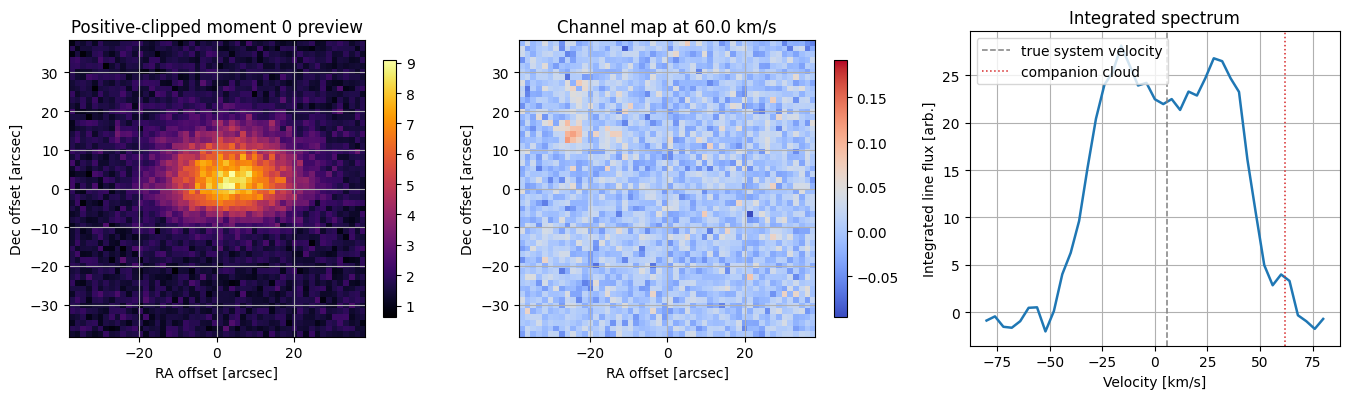

In [3]:
preview_moment0 = np.sum(np.clip(cube, 0.0, None), axis=0) * dv_kms
companion_chan = np.argmin(np.abs(vel_kms - companion_velocity_kms))
integrated_spectrum = np.sum(cube, axis=(1, 2))

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.1))

im0 = axes[0].imshow(
    preview_moment0,
    origin="lower",
    extent=extent_arcsec,
    cmap="inferno",
)
axes[0].set_title("Positive-clipped moment 0 preview")
axes[0].set_xlabel("RA offset [arcsec]")
axes[0].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im0, ax=axes[0], shrink=0.82)

im1 = axes[1].imshow(
    cube[companion_chan],
    origin="lower",
    extent=extent_arcsec,
    cmap="coolwarm",
    vmin=-4.0 * cube_rms,
    vmax=8.0 * cube_rms,
)
axes[1].set_title(f"Channel map at {vel_kms[companion_chan]:.1f} km/s")
axes[1].set_xlabel("RA offset [arcsec]")
axes[1].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im1, ax=axes[1], shrink=0.82)

axes[2].plot(vel_kms, integrated_spectrum, color="tab:blue", lw=1.8)
axes[2].axvline(v_sys_true, color="gray", ls="--", lw=1.1, label="true system velocity")
axes[2].axvline(companion_velocity_kms, color="tab:red", ls=":", lw=1.1, label="companion cloud")
axes[2].set_xlabel("Velocity [km/s]")
axes[2].set_ylabel("Integrated line flux [arb.]")
axes[2].set_title("Integrated spectrum")
axes[2].legend(loc="upper left")

plt.tight_layout()

print(f"积分谱线峰值约出现在 {vel_kms[np.argmax(integrated_spectrum)]:.1f} km/s")
print(f"伴随云团通道 {vel_kms[companion_chan]:.1f} km/s 上的最大像素值 ≈ {cube[companion_chan].max():.3f}")


### 9.13.2 用平滑辅助的双阈值法构造 `3D mask`

谱线 source finding 里最常见的思路之一是：

- 先在平滑后的 cube 上寻找高显著性 seeds；
- 再把这些 seeds 向较低阈值的邻近体素生长；
- 最后做连通域分离，并丢掉明显太小、太窄的伪分量。

这背后的专业判断是：**检测和测量通常不应使用完全相同的 mask。** 平滑后的 cube 更利于检测弱发射，但真正的测量仍应回到原始分辨率 cube 上完成。


smoothed cube RMS ≈ 0.0036
seed threshold ≈ 0.0180, grow threshold ≈ 0.0093
最终保留下来的 3D 分量数 = 2
label  voxels  v-range[km/s]    centroid[arcsec]      peak[km/s]  flux proxy
----------------------------------------------------------------------------
    1   10619   -48.0..60.0    (   5.0,    5.0)       8.0     1905.15
    2     283    52.0..72.0    ( -21.4,   18.7)      64.0       26.27


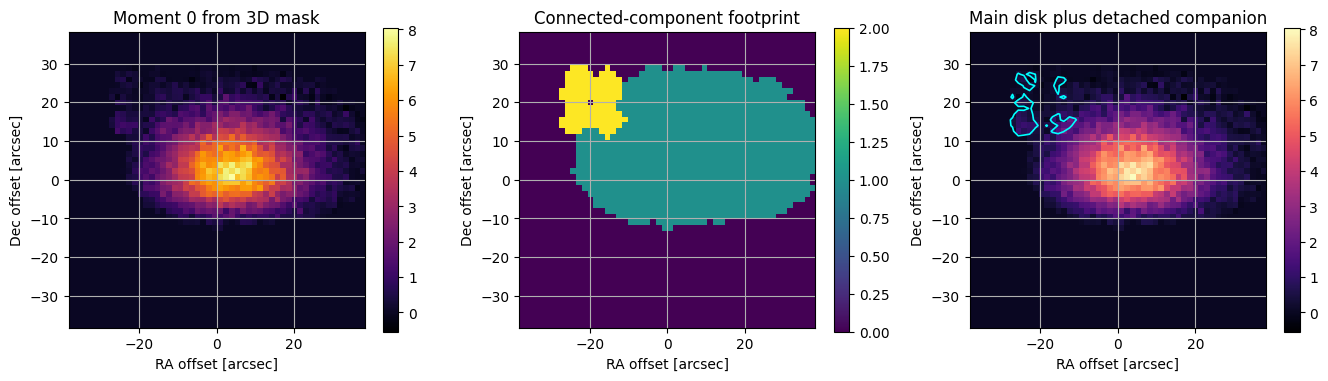

In [4]:
smoothed_cube = spatial_smooth(
    spectral_smooth(cube),
    gaussian_kernel(npix=7, sigma_pix=1.25),
)
smoothed_rms = robust_rms(smoothed_cube[line_free_mask])

seed_threshold = 5.0 * smoothed_rms
grow_threshold = 2.6 * smoothed_rms
seed_mask = smoothed_cube > seed_threshold
grow_mask = smoothed_cube > grow_threshold

mask_3d = seed_mask.copy()
for _ in range(2):
    mask_3d = grow_mask & dilate6(mask_3d)

labels_3d, n_components = connected_components_3d(
    mask_3d,
    min_voxels=40,
    min_chan=3,
)
catalog_rows = component_catalog(
    cube=cube,
    labels=labels_3d,
    vel_kms=vel_kms,
    x_arcsec=x_arcsec,
    y_arcsec=y_arcsec,
    dv_kms=dv_kms,
)

all_mask_moment0 = np.sum(np.where(mask_3d, cube, 0.0), axis=0) * dv_kms
component_footprint = np.max(labels_3d, axis=0)

main_label = catalog_rows[0]["label"]
companion_label = catalog_rows[1]["label"]
main_mask_3d = labels_3d == main_label
companion_mask_3d = labels_3d == companion_label
main_moment0 = np.sum(np.where(main_mask_3d, cube, 0.0), axis=0) * dv_kms
companion_moment0 = np.sum(np.where(companion_mask_3d, cube, 0.0), axis=0) * dv_kms

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.1))

im0 = axes[0].imshow(
    all_mask_moment0,
    origin="lower",
    extent=extent_arcsec,
    cmap="inferno",
)
axes[0].set_title("Moment 0 from 3D mask")
axes[0].set_xlabel("RA offset [arcsec]")
axes[0].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im0, ax=axes[0], shrink=0.82)

im1 = axes[1].imshow(
    component_footprint,
    origin="lower",
    extent=extent_arcsec,
    cmap="viridis",
    vmin=0.0,
    vmax=max(2, n_components),
)
axes[1].set_title("Connected-component footprint")
axes[1].set_xlabel("RA offset [arcsec]")
axes[1].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im1, ax=axes[1], shrink=0.82)

im2 = axes[2].imshow(
    main_moment0 + companion_moment0,
    origin="lower",
    extent=extent_arcsec,
    cmap="magma",
)
axes[2].contour(
    companion_moment0,
    levels=[0.20 * companion_moment0.max()],
    colors="cyan",
    linewidths=1.2,
    origin="lower",
    extent=extent_arcsec,
)
axes[2].set_title("Main disk plus detached companion")
axes[2].set_xlabel("RA offset [arcsec]")
axes[2].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im2, ax=axes[2], shrink=0.82)

plt.tight_layout()

print(f"smoothed cube RMS ≈ {smoothed_rms:.4f}")
print(f"seed threshold ≈ {seed_threshold:.4f}, grow threshold ≈ {grow_threshold:.4f}")
print(f"最终保留下来的 3D 分量数 = {n_components}")
print(format_catalog(catalog_rows))


上面的目录已经足以支撑一个很基础但专业上正确的判断：

- 最大分量是主盘；
- 第二个分量是偏高速度、偏离盘中心的伴随云团；
- 只有在把它们先分开之后，后面的 `PV` 分析和旋转曲线拟合才不会被混淆。

这一步的意义并不是“得到一个漂亮的表格”，而是让后续的科学测量真正拥有对象级别的边界条件。


### 9.13.3 只保留主盘，抽取 `PV diagram` 与 ridge

这里采用一个非常常见的入门做法：先用主盘分量的 mask 限定测量区域，再沿主轴附近做一个小宽度切片，把二维 `PV diagram` 画出来。

需要特别强调的是：`PV diagram` 既不是 moment 1 的替代品，也不是自动给出旋转曲线的按钮。它更像是一个诊断平面，帮助你判断：

- 主盘是否具有近似规则的旋转结构；
- 中心区域是否受 beam smearing 显著影响；
- 是否仍有次级分量混进主盘切片。


主轴切片中心约位于 y = 2.2 arcsec
主盘积分谱线估计得到的系统速度 ≈ 6.09 km/s
用于拟合的 ridge 点数 = 32


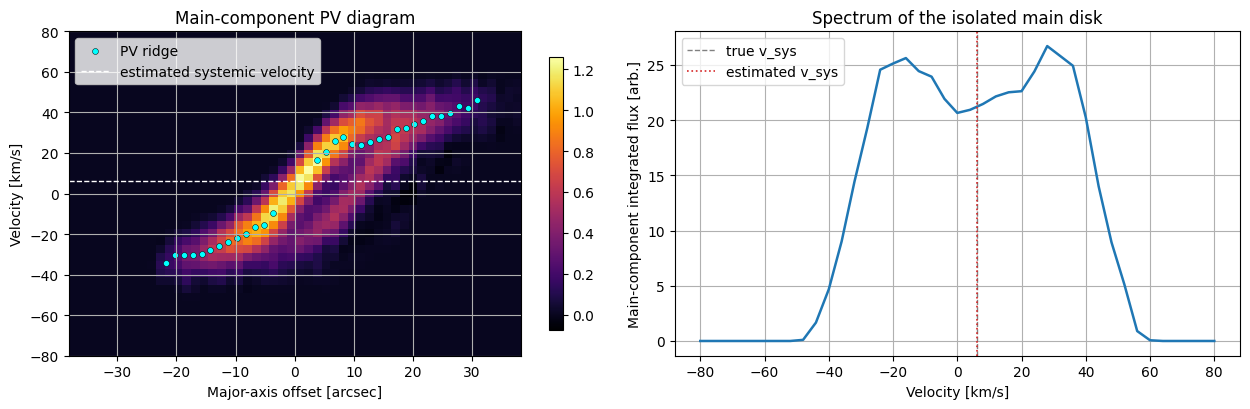

In [5]:
main_spectrum = np.sum(np.where(main_mask_3d, cube, 0.0), axis=(1, 2))
main_positive_spectrum = np.clip(main_spectrum, 0.0, None)
v_sys_est = np.sum(vel_kms * main_positive_spectrum) / np.sum(main_positive_spectrum)

disk_moment0 = np.sum(np.where(main_mask_3d, cube, 0.0), axis=0) * dv_kms
major_axis_y_index = np.argmax(disk_moment0.sum(axis=1))
major_axis_y_arcsec = y_arcsec[major_axis_y_index]
pv_half_width_pix = 2
pv_slice = slice(
    max(0, major_axis_y_index - pv_half_width_pix),
    min(ny, major_axis_y_index + pv_half_width_pix + 1),
)
pv_diagram = np.sum(
    np.where(main_mask_3d[:, pv_slice, :], cube[:, pv_slice, :], 0.0),
    axis=1,
)
pv_smoothed = spectral_smooth(pv_diagram)

column_peak = np.max(pv_smoothed, axis=0)
ridge_velocity = np.full(nx, np.nan)
ridge_valid = (column_peak > 0.12 * column_peak.max()) & (np.abs(x_arcsec) > 3.0)

for x_index in range(nx):
    profile = np.clip(pv_smoothed[:, x_index], 0.0, None)
    if profile.max() <= 0.0:
        continue
    high_mask = profile > 0.55 * profile.max()
    ridge_velocity[x_index] = np.sum(vel_kms[high_mask] * profile[high_mask]) / np.sum(profile[high_mask])

ridge_valid &= np.isfinite(ridge_velocity)
pv_extent = [x_arcsec[0], x_arcsec[-1], vel_kms[0], vel_kms[-1]]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))

im = axes[0].imshow(
    pv_smoothed,
    origin="lower",
    extent=pv_extent,
    aspect="auto",
    cmap="inferno",
)
axes[0].scatter(
    x_arcsec[ridge_valid],
    ridge_velocity[ridge_valid],
    s=18,
    color="cyan",
    edgecolor="black",
    linewidth=0.35,
    label="PV ridge",
)
axes[0].axhline(v_sys_est, color="white", ls="--", lw=1.0, label="estimated systemic velocity")
axes[0].set_xlabel("Major-axis offset [arcsec]")
axes[0].set_ylabel("Velocity [km/s]")
axes[0].set_title("Main-component PV diagram")
axes[0].legend(loc="upper left")
plt.colorbar(im, ax=axes[0], shrink=0.84)

axes[1].plot(vel_kms, main_spectrum, color="tab:blue", lw=1.8)
axes[1].axvline(v_sys_true, color="gray", ls="--", lw=1.0, label="true v_sys")
axes[1].axvline(v_sys_est, color="tab:red", ls=":", lw=1.2, label="estimated v_sys")
axes[1].set_xlabel("Velocity [km/s]")
axes[1].set_ylabel("Main-component integrated flux [arb.]")
axes[1].set_title("Spectrum of the isolated main disk")
axes[1].legend(loc="upper left")

plt.tight_layout()

print(f"主轴切片中心约位于 y = {major_axis_y_arcsec:.1f} arcsec")
print(f"主盘积分谱线估计得到的系统速度 ≈ {v_sys_est:.2f} km/s")
print(f"用于拟合的 ridge 点数 = {ridge_valid.sum()}")


从这里开始，就要有一个更像专业分析而不是课堂演示的意识：**我们看到的 ridge 不是“真实旋转曲线”，而是“被有限角分辨率、谱线宽度和切片方式共同卷积过的观测摘要”。**

因此下一步的拟合只能被理解为“简化入口”，而不是最终科学结论。真正的高精度工作通常需要 tilted-ring、厚盘模型、beam-smearing 修正，甚至直接在 3D cube 上做 forward modeling。


### 9.13.4 做一个最小但专业上自洽的旋转曲线拟合

下面用一个简化的 arctan 模型去拟合主盘的 `PV ridge`。它的优点是参数少、可解释性强，足够作为培训页的第一层入口：

- `v_sys` 用主盘积分谱线估计值固定；
- `v_flat` 描述外盘接近平坦时的特征速度；
- `r_turn` 描述从固体体式上升过渡到平坦段的大致尺度。

这一步最值得学习的不是“拟合成功了”，而是比较输入真值和恢复结果之间的差异，并认识到 beam smearing 会把简单 ridge 拟合系统性地拉向较低的外盘速度。


拟合结果：v_sys ≈ 6.09 km/s, v_flat ≈ 47.50 km/s, r_turn ≈ 7.50 arcsec
输入真值：v_sys = 6.00 km/s, v_flat = 56.00 km/s, r_turn = 8.00 arcsec
参数偏差：Δv_flat ≈ -8.50 km/s, Δr_turn ≈ -0.50 arcsec
ridge 拟合的均方根残差 ≈ 4.80 km/s


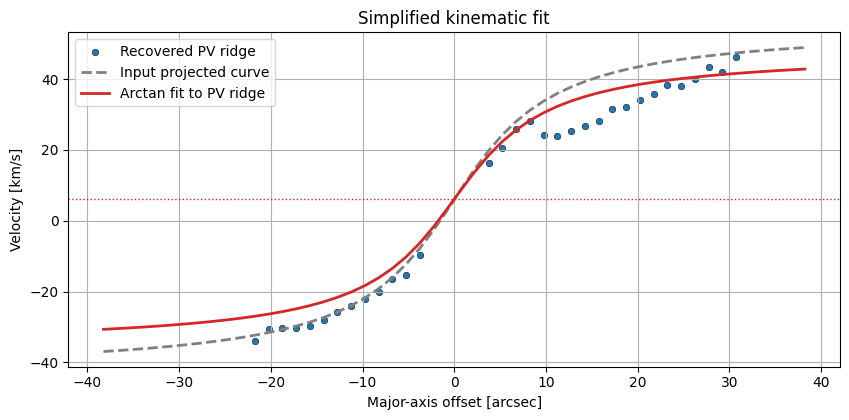

In [6]:
fit_v_flat, fit_r_turn, fit_score = fit_arctan_curve(
    radius_arcsec=x_arcsec[ridge_valid],
    velocity_kms=ridge_velocity[ridge_valid],
    v_sys=v_sys_est,
    inclination_deg=inclination_deg,
)
fitted_curve = projected_arctan_velocity(
    x_arcsec,
    v_sys=v_sys_est,
    v_flat=fit_v_flat,
    r_turn=fit_r_turn,
    inclination_deg=inclination_deg,
)
true_curve = projected_arctan_velocity(
    x_arcsec,
    v_sys=v_sys_true,
    v_flat=v_flat_true,
    r_turn=r_turn_true,
    inclination_deg=inclination_deg,
)

fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(
    x_arcsec[ridge_valid],
    ridge_velocity[ridge_valid],
    s=22,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.35,
    label="Recovered PV ridge",
)
ax.plot(x_arcsec, true_curve, color="gray", lw=2.0, ls="--", label="Input projected curve")
ax.plot(x_arcsec, fitted_curve, color="tab:red", lw=2.0, label="Arctan fit to PV ridge")
ax.axhline(v_sys_est, color="tab:red", lw=1.0, ls=":")
ax.set_xlabel("Major-axis offset [arcsec]")
ax.set_ylabel("Velocity [km/s]")
ax.set_title("Simplified kinematic fit")
ax.legend(loc="upper left")
plt.tight_layout()

print(
    f"拟合结果：v_sys ≈ {v_sys_est:.2f} km/s, "
    f"v_flat ≈ {fit_v_flat:.2f} km/s, r_turn ≈ {fit_r_turn:.2f} arcsec"
)
print(
    f"输入真值：v_sys = {v_sys_true:.2f} km/s, "
    f"v_flat = {v_flat_true:.2f} km/s, r_turn = {r_turn_true:.2f} arcsec"
)
print(
    f"参数偏差：Δv_flat ≈ {fit_v_flat - v_flat_true:+.2f} km/s, "
    f"Δr_turn ≈ {fit_r_turn - r_turn_true:+.2f} arcsec"
)
print(f"ridge 拟合的均方根残差 ≈ {np.sqrt(fit_score):.2f} km/s")


这个结果非常适合作为训练页里的“第一层专业判断”：

- 主盘系统速度恢复得相当稳定；
- 简化 arctan 模型已经能抓住主盘整体旋转结构；
- `v_flat` 往往会比输入真值偏低，因为我们现在拟合的是已经被 beam smearing 和有限谱线宽度“压平”的 `PV ridge`，而不是未卷积的三维动力学模型。

也正因为如此，真正的高级谱线工作流通常不会止步于这里，而会继续进入 tilted-ring、3D forward modeling、误差传播和模型比较。


### 9.13.5 与真实工作流的对应

如果把这一页映射回更真实的软件环境，典型工作流大致会长成下面这样：

- 先做 line cube imaging，并建立 line-free 通道和噪声模型；
- 用平滑辅助检测或专门的 source finder 构造 `3D mask`；
- 输出组件目录，确认哪些发射属于主盘、伴星系、潮汐尾或外流结构；
- 沿主轴或物理上更合理的几何参数做 `PV diagram`；
- 再进入 tilted-ring、3DBarolo / TiRiFiC 一类的运动学建模或更完整的 3D 前向拟合。

这一页最想建立的专业习惯是：**高级谱线分析不是把 moment 0 和 moment 1 再画得更漂亮，而是把“检测边界、组件分离、诊断图、运动学模型”连成一条可重复的分析链。**
